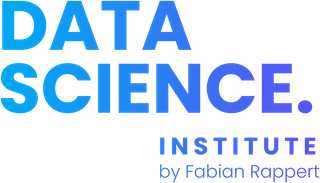

# Inhaltsverzeichnis 

- **Aufgaben zu BeautifulSoup**
    - **Aufgabe 1:  Daten extrahieren**
    - **Aufgabe 2: Filter einbauen**


# Aufgaben zu BeautifulSoup

Die Webseite *https://hckrnews.com/*   fasst aktuelle Technologienachrichten in einer Liste zusammen. 

Wir wollen mit `BeautifulSoup` diese Informationen auslesen.

## Aufgabe 1:  Daten extrahieren


- Lass die URL *https://hckrnews.com/* über `requests` auslesen. Betrachte das Ergebnis mit BeautifulSoup. 

- Versuche herauszufinden, unter welchem Tag die Artikel dargestellt werden.

- Lass dir alle Überschriften der Artikel ausgeben. 

- Lass dir zusätzlich noch den Link ausgeben, womit man zum Artikel kommt.

In [1]:
import requests
from bs4 import BeautifulSoup

In [2]:
res = requests.get("https://hckrnews.com/")
soup = BeautifulSoup(res.text, "html.parser")

In [3]:
print(soup.prettify()[:2000])  # First 2000 characters

<!DOCTYPE html>
<html class="no-js" lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   hckr news - Hacker News sorted by time
  </title>
  <meta content="An unofficial, alternative interface
to Hacker News" name="description"/>
  <meta content="Wayne Larsen" name="author"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <meta content="width=device-width" name="viewport"/>
  <!-- Home screen icon  Mathias Bynens mathiasbynens.be/notes/touch-icons -->
  <!-- For third generation iPad Retina Display -->
  <link href="/img/touch/apple-touch-icon-144x144-precomposed.png" rel="apple-touch-icon-precomposed" sizes="144x144"/>
  <!-- For iPhone 4 with high-resolution Retina display: -->
  <link href="/img/touch/apple-touch-icon-114x114-precomposed.png" rel="apple-touch-icon-precomposed" sizes="114x114"/>
  <!-- For first-generation iPad: -->
  <link href="/img/touch/apple-touch-icon-72x72-precomposed.png" rel="apple-touch-icon-precomposed" sizes="72x72"/>
  <!-- For 

In [4]:
all_tags = set()
for tag in soup.find_all():
    all_tags.add(tag.name)

print("All tags on this page:")
for tag in sorted(all_tags):
    print(tag)

All tags on this page:
a
body
div
h1
h3
head
header
html
li
link
meta
p
script
span
title
ul


In [5]:
all_classes = set()
for element in soup.find_all(class_=True):
    classes = element.get("class")
    for class_name in classes:
        all_classes.add(class_name)

print("All CSS classes on this page:")
for class_name in sorted(all_classes):
    print(class_name)

All CSS classes on this page:
about
by10
by20
byall
byhalf
byhomepage
comments
container
dead
entries
entry
filters
filtertop
hidden-phone
hn
homepage
io
job
link
logo
mainnav
menu
nav
nav-pills
no-js
offset1
offset3
points
pull-right
row
settings
show-settings
source
span1
span15
span2
span3
span5
span9
story
unstyled
visible-phone


In [6]:
titles = soup.find_all("title")
if titles:
    print("No title found")
else:
    for title in titles:
        print(f"Title: {title.string}")

No title found


In [7]:
article_links = soup.find_all("a", class_="link")

for link in article_links:
    title = (
        link.get_text().strip()
    )  # .get_text extracts *visible text content*, aka what users see and click on
    url = link.get("href")
    if title:
        print(f"Title: {title}")
        print(f"Link: {url}")
        print()

Title: The Stagnant Order. and the End of Rising Powers (www.foreignaffairs.com)
Link: https://www.foreignaffairs.com/united-states/stagnant-order-michael-beckley

Title: Tesla Recalls Almost 13,000 EVs over Risk of Battery Power Loss (www.bloomberg.com)
Link: https://www.bloomberg.com/news/articles/2025-10-22/tesla-recalls-almost-13-000-evs-over-risk-of-battery-power-loss

Title: Distributed Ray-Tracing (www.4rknova.com)
Link: https://www.4rknova.com//blog/2019/02/24/distributed-raytracing

Title: Jaguar Land Rover hack cost UK economy an estimated $2.5B (www.reuters.com)
Link: https://www.reuters.com/sustainability/boards-policy-regulation/jaguar-land-rover-hack-cost-uk-economy-25-billion-report-says-2025-10-22/

Title: Subprime Lender PrimaLend Enters Bankruptcy After Bond Default (www.bloomberg.com)
Link: https://www.bloomberg.com/news/articles/2025-10-22/subprime-lender-primalend-enters-bankruptcy-after-bond-default

Title: Internet's biggest annoyance: Cookie laws should target b

## Aufgabe 2: Filter einbauen

- Baue einen Filter deiner Wahl ein. Lasse dir nur die Artikel anzeigen, die das Wort `Python` enthalten.

In [8]:
links = soup.find_all("a")
for link in links:
    title = link.get_text().strip()
    if "python" in title.lower():
        url = link.get("href")
        print(f"Title: {title}")
        print(f"Link: {url}")

Title: Show HN: Modshim â A new alternative to monkey-patching in Python (github.com)
Link: https://github.com/joouha/modshim
